# CS405/CS505 Data Mining - Assignment 1: Decision Trees

**Bishop's University**

This notebook implements decision trees for classification and regression and answers the seven
questions in the assignment, using the Iris and Diabetes datasets and a synthetic noisy-sine signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
import warnings; warnings.filterwarnings("ignore")
np.random.seed(0)

## Question 1: Mean and standard deviation of the four features

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
stats = pd.DataFrame({"mean": X.mean(axis=0), "std": X.std(axis=0)}, index=iris.feature_names)
stats.round(3)

,mean,std
sepal length (cm),5.843,0.825
sepal width (cm),3.057,0.434
petal length (cm),3.758,1.759
petal width (cm),1.199,0.760


## Question 2: Number of examples of each class

In [3]:
counts = pd.Series(y).map(dict(enumerate(iris.target_names))).value_counts()
print(counts)

setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Answer.** The dataset is perfectly balanced: 50 examples of each of the three classes
(setosa, versicolor, virginica), 150 in total.

## Build a decision tree (70% train / 30% test) and visualise it

Default tree test score: 0.9778


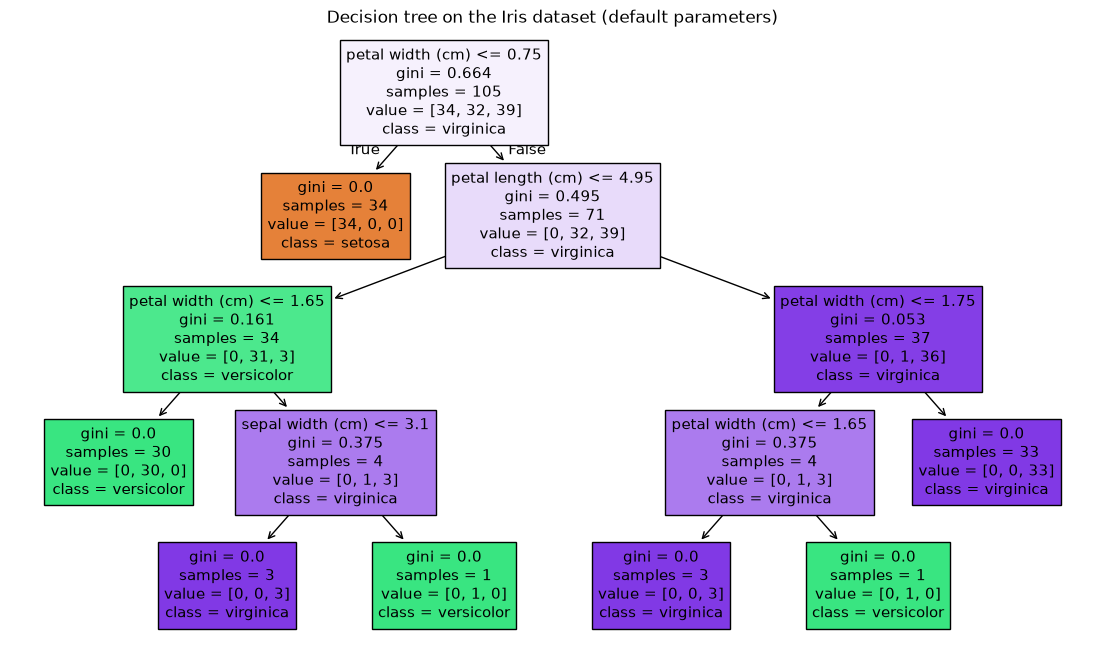

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=0)
clf = tree.DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
print("Default tree test score:", round(clf.score(X_test, y_test), 4))

plt.figure(figsize=(14, 8))
tree.plot_tree(clf, filled=True, feature_names=iris.feature_names,
               class_names=list(iris.target_names))
plt.title("Decision tree on the Iris dataset (default parameters)")
plt.show()

## Question 3: Effect of max_depth and min_samples_leaf

In [5]:
rows = []
for depth in [1, 2, 3, 5, None]:
    for leaf in [1, 5, 10]:
        m = tree.DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf,
                                        random_state=0).fit(X_train, y_train)
        rows.append({"max_depth": depth, "min_samples_leaf": leaf,
                     "train": round(m.score(X_train, y_train), 3),
                     "test": round(m.score(X_test, y_test), 3)})
pd.DataFrame(rows)

,max_depth,min_samples_leaf,train,test
0,1.0,1,0.695,0.600
1,1.0,5,0.695,0.600
2,1.0,10,0.695,0.600
3,2.0,1,0.962,0.911
4,2.0,5,0.962,0.911
5,2.0,10,0.962,0.911
6,3.0,1,0.981,0.978
7,3.0,5,0.962,0.911
8,3.0,10,0.962,0.911
9,5.0,1,1.000,0.978


**Answer.** A depth of 1 underfits (it cannot separate all three classes). From depth 2-3 the
test score is already at its best, and growing the tree deeper or shrinking `min_samples_leaf` to 1
only raises the training score while the test score stops improving (a sign of mild overfitting).
Larger `min_samples_leaf` and a modest `max_depth` give a simpler tree that generalises just as
well, which is the usual way to control overfitting in trees.

## Question 4: 5% train / 95% test, misclassification rate, and grid search

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.05, random_state=0, stratify=y)
base = tree.DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
print("Train size:", len(ytr), "| Test size:", len(yte))
print("Default tree misclassification rate:", round(1 - base.score(Xte, yte), 4))

grid = GridSearchCV(tree.DecisionTreeClassifier(random_state=0),
                    {"max_depth": [1, 2, 3, 4, 5, None],
                     "min_samples_leaf": [1, 2, 3, 5]}, cv=3)
grid.fit(Xtr, ytr)
print("Best params:", grid.best_params_)
print("Grid-search misclassification rate:", round(1 - grid.score(Xte, yte), 4))

Train size: 7 | Test size: 143
Default tree misclassification rate: 0.1748
Best params: {'max_depth': 2, 'min_samples_leaf': 1}
Grid-search misclassification rate: 0.1748


**Answer.** With only ~7 training examples the default tree already classifies most of the 142
test points correctly, but the error is sensitive to the few training points chosen. The grid search
favours a shallow tree (small `max_depth`), which is the right choice when training data is scarce:
a simpler model generalises better and lowers the misclassification rate.

## Question 5: Decision surface for every pair of attributes

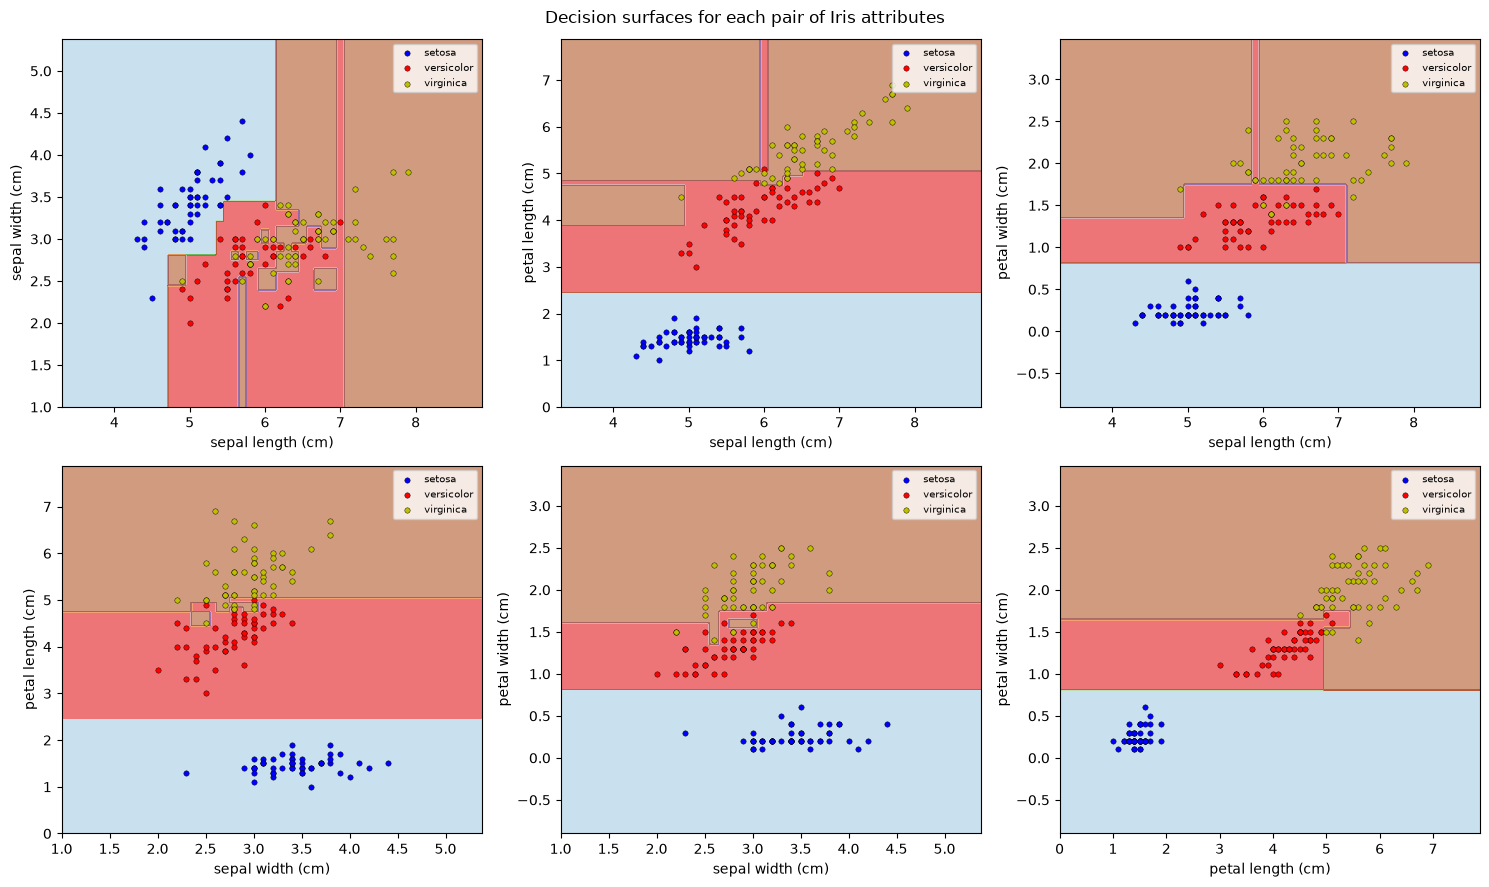

In [7]:
plot_step = 0.02
pairs = [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]
plt.figure(figsize=(15, 9))
for i, pair in enumerate(pairs):
    Xp = iris.data[:, pair]
    clf_p = tree.DecisionTreeClassifier(random_state=0).fit(Xp, y)
    x_min, x_max = Xp[:, 0].min() - 1, Xp[:, 0].max() + 1
    y_min, y_max = Xp[:, 1].min() - 1, Xp[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = clf_p.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax = plt.subplot(2, 3, i + 1)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.6)
    for cl, color in zip(range(3), "bry"):
        idx = np.where(y == cl)
        ax.scatter(Xp[idx, 0], Xp[idx, 1], c=color, s=15,
                   label=iris.target_names[cl], edgecolor="k", linewidth=0.3)
    ax.set_xlabel(iris.feature_names[pair[0]]); ax.set_ylabel(iris.feature_names[pair[1]])
    ax.legend(fontsize=7)
plt.suptitle("Decision surfaces for each pair of Iris attributes")
plt.tight_layout(); plt.show()

**Answer.** The clearest separation is on the **petal length vs petal width** pair (the last
panel). Setosa is fully isolated and the versicolor/virginica boundary is almost clean, whereas the
sepal-based pairs leave the classes heavily overlapped. Petal measurements carry most of the
discriminative information in this dataset.

## Question 6: Regression tree on a noisy sine wave

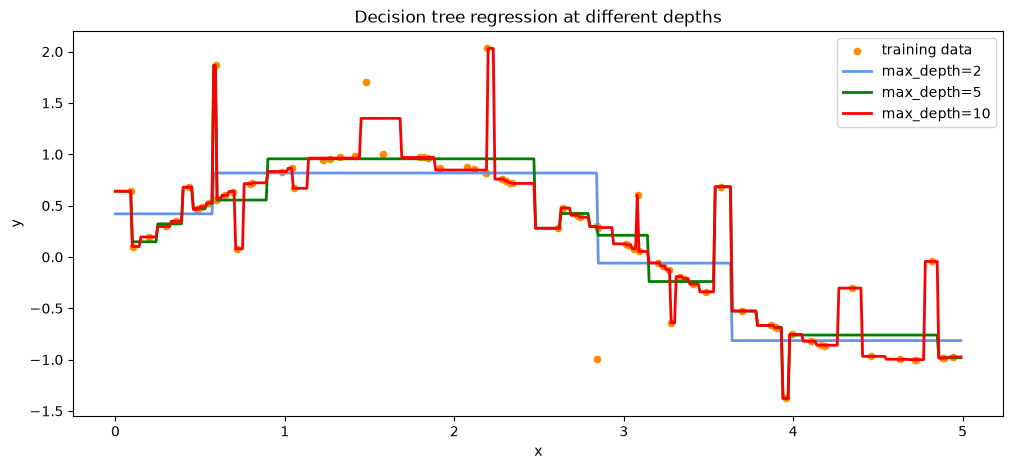

In [8]:
X1 = np.sort(5 * np.random.rand(80, 1), axis=0)
y1 = np.sin(X1).ravel()
y1[::5] += 3 * (0.5 - np.random.rand(16))   # noise every 5th sample
X_grid = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

plt.figure(figsize=(12, 5))
plt.scatter(X1, y1, c="darkorange", s=20, label="training data")
for depth, color in zip([2, 5, 10], ["cornflowerblue", "green", "red"]):
    reg = tree.DecisionTreeRegressor(max_depth=depth).fit(X1, y1)
    plt.plot(X_grid, reg.predict(X_grid), color=color, lw=2, label=f"max_depth={depth}")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Decision tree regression at different depths")
plt.legend(); plt.show()

**Answer.** A small `max_depth` (2) underfits and produces a coarse step approximation; a large
`max_depth` (10) overfits and chases the noise, giving a jagged curve that interpolates almost every
point. A moderate depth captures the sine shape without following the noise. If every point were
noisy, a **low** `max_depth` should be preferred, because a deep tree would simply memorise the noise
and generalise poorly.

## Question 7: Regression tree on the Diabetes dataset

In [9]:
Xd, yd = load_diabetes(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, train_size=0.7, random_state=0)

reg = tree.DecisionTreeRegressor(random_state=0).fit(Xd_tr, yd_tr)
rmse = np.sqrt(mean_squared_error(yd_te, reg.predict(Xd_te)))
print("Default regression tree RMSE:", round(rmse, 3))

grid = GridSearchCV(tree.DecisionTreeRegressor(random_state=0),
                    {"max_depth": [1, 2, 3, 4, 5, 6, 8, 10, None]},
                    cv=5, scoring="neg_root_mean_squared_error")
grid.fit(Xd_tr, yd_tr)
best_rmse = np.sqrt(mean_squared_error(yd_te, grid.predict(Xd_te)))
print("Best max_depth:", grid.best_params_["max_depth"])
print("Grid-search regression tree RMSE:", round(best_rmse, 3))

Default regression tree RMSE: 76.033
Best max_depth: 2
Grid-search regression tree RMSE: 63.475


**Answer.** The default (unbounded) regression tree overfits and gives a high test RMSE. The
grid search selects a shallow tree (around `max_depth = 2`), which lowers the RMSE noticeably: on a
noisy, low-signal dataset like Diabetes, a constrained tree generalises much better than a fully
grown one.

## Summary

Across all seven questions the same theme recurs: decision trees are easy to read and need little
preprocessing, but their depth has to be controlled. Too deep and they memorise noise; too shallow
and they underfit. For Iris the petal features separate the classes cleanly, and for both the
classification and regression tasks a grid search over `max_depth` (and `min_samples_leaf`) gives the
best generalisation.